In [6]:
from time import perf_counter

import torch
import torch.nn.functional as F

# Mean Pooling - Take attention mask into account for correct averaging
def embedding(model_output, attention_mask):
    token_embeddings = model_output[0]
    input_mask_expanded = attention_mask.unsqueeze(
        -1).expand(token_embeddings.size()).float()
    mean = torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)
    return F.normalize(mean, p=2, dim=1)

def calculate_similarity(sentences, tokenizer, qnpu_model, torch_model):
    encoded_input = tokenizer(
        sentences,
        padding="max_length",
        max_length=qnpu_model.sequence_length,
        truncation=True,
        add_special_tokens=True,
        return_tensors="pt",
    )

    start = perf_counter()
    output = qnpu_model(**encoded_input)
    print(f"NPU inference: {round((perf_counter() - start)*1000)}ms")
    embeds_1 = embedding(output, encoded_input['attention_mask'])

    with torch.no_grad():
        start = perf_counter()
        output = torch_model(**encoded_input)
        print(f"CPU inference: {round((perf_counter() - start)*1000)}ms")
        embeds_2 = embedding(output, encoded_input['attention_mask'])

    return F.cosine_similarity(embeds_1, embeds_2)

In [2]:
from pathlib import Path

model_name = "sentence-transformers/all-MiniLM-L6-v2"
qnpu_model_path = Path("outputs/sbert/all_minilm_l6_v2/model.onnx")

In [4]:
from transformers import AutoModel, AutoTokenizer
from qnpumodel import QNPUBertModel

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = QNPUBertModel(
    qnpu_model_path=qnpu_model_path,
    device="npu",
    qnpu_config={
        "disable_cpu_fallback": "0",
    },
)
torch_model = AutoModel.from_pretrained(model_name).eval()

In [11]:
from datasets import load_dataset

def prepare_data():
    dataset = load_dataset("glue", "mrpc", split="test[:100]")
    sentences = dataset["sentence1"] + dataset["sentence2"]
    return sentences

In [12]:
setences = prepare_data()
scores = calculate_similarity(setences, tokenizer, model, torch_model)
average_score = torch.mean(scores)
print(f"Average score: {round(average_score.item(), 3)}")
p90_score = torch.quantile(scores, 0.90)
print(f"P90 score: {round(p90_score.item(), 3)}")

100%|██████████| 200/200 [00:00<00:00, 567.68it/s]


NPU inference: 433ms
CPU inference: 4946ms
Average score: 0.986
P90 score: 0.99


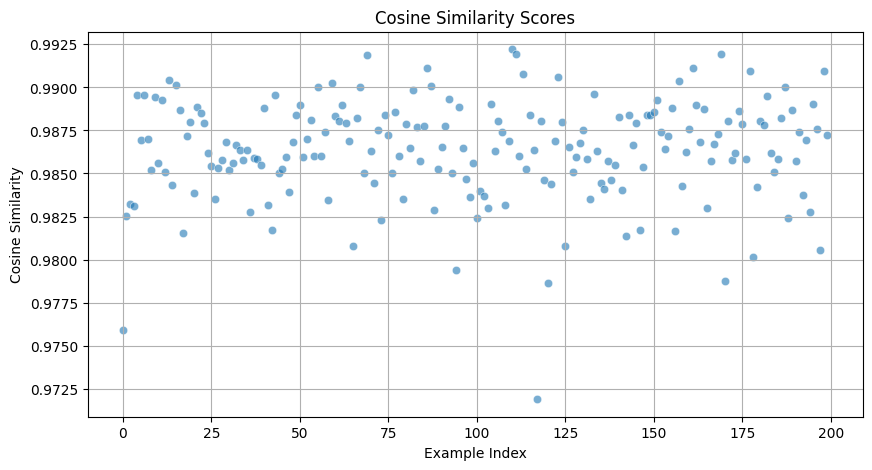

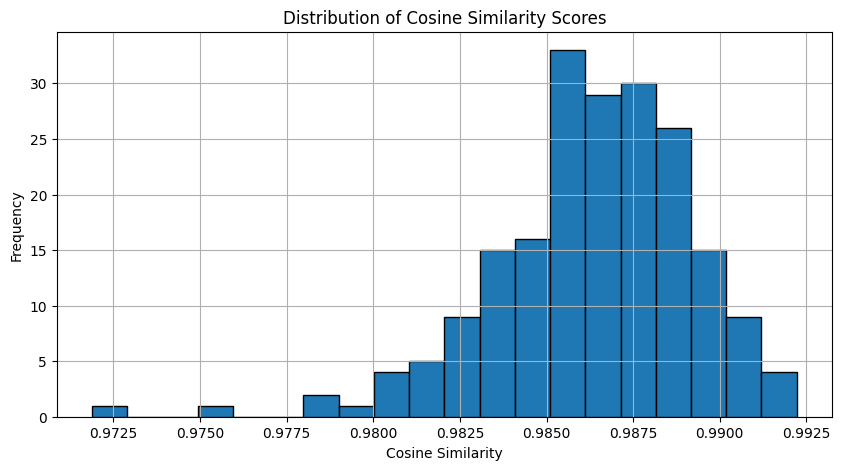

In [14]:
import matplotlib.pyplot as plt

# Plot the scores as a scatter plot
plt.figure(figsize=(10, 5))
plt.scatter(range(len(scores)), scores, alpha=0.6,
            edgecolors='w', linewidth=0.5)
plt.title('Cosine Similarity Scores')
plt.xlabel('Example Index')
plt.ylabel('Cosine Similarity')
plt.grid(True)
plt.show()

# Plot the scores as a histogram
plt.figure(figsize=(10, 5))
plt.hist(scores, bins=20, edgecolor='black')
plt.title('Distribution of Cosine Similarity Scores')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()